In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Setting the style for visualizations
sns.set_theme(style="whitegrid")

# Load the CSV
df = pd.read_csv("../data/Ethiopia/ethiopia.csv")

# Add Country column
df["Country"] = "Ethiopia"

# Convert YEAR and DOY to datetime
# Format %Y%j handles Year + Day of Year (1-366)
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

#Printing the size of the data and viewing the top 5 rows of the data
print("Size of the dataset for Ethiopia is", df.shape)
df.head()


Size of the dataset for Ethiopia is (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [5]:
# 1. Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# 2. Handle Duplicates and print them if there are any
duplicates = df.duplicated().sum()
print(f"Total Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report
null_report = df.isna().sum()
null_percent = (null_report / len(df)) * 100
print("Percentage of missing values per column:")
print(null_percent) 

# Run summary statistics for all numeric columns
df.describe()

Total Duplicate rows found: 0
Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


Data Quality Interpretation:

* Missing Values: After replacing NASA sentinel values (-999), the dataset contains 0% missing values across all columns. This indicates a high-quality, coninuous record for the Ethiopia climate data.
* Duplicates: No duplicate rows were detected, ensuring that time-series observations are unique.
* Summary Stats: The average temprature is approximately 16.06850°C, with a maximum of 23.199175°C

In [6]:
from scipy import stats
import numpy as np

# Columns to check for outliers
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (number of standard deviations away from the mean)
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any column has a Z-score > 3
outlier_rows = (z_scores > 3).any(axis=1)
outlier_count = outlier_rows.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {outlier_count}")

# Display outlier counts per specific column
outliers_per_col = (z_scores > 3).sum()
print("\nOutliers detected per column:", outliers_per_col)
print("")


## The following code displays the first 20 rows that contain
## atleast one outlier, highlighing the extreme values.

# Convert the mask to a DataFrame so we can use Pandas tools
outlier_mask = (z_scores > 3)
outlier_mask_df = pd.DataFrame(outlier_mask, columns=cols_to_check)

# This creates a summary showing which columns were outliers for the flagged rows
# We filter it to only show rows where at least one value is True
flagged_only = outlier_mask_df[outlier_mask_df.any(axis=1)]

print(f"Showing the 'culprit' columns for the first 20 outliers:")
for index, row in flagged_only.head(20).iterrows():
    # Get the column names where the value is True
    flagged_cols = row[row == True].index.tolist()
    
    # Get the date from the original dataframe using the index
    obs_date = df.loc[index, 'Date'].date()
    
    print(f"Row {index} (Date: {obs_date}): Outliers in {flagged_cols}")

Total rows flagged as outliers (|Z| > 3): 132

Outliers detected per column: 137

Showing the 'culprit' columns for the first 20 outliers:
Row 144 (Date: 2015-05-25): Outliers in ['PRECTOTCORR']
Row 145 (Date: 2015-05-26): Outliers in ['PRECTOTCORR']
Row 177 (Date: 2015-06-27): Outliers in ['PRECTOTCORR']
Row 214 (Date: 2015-08-03): Outliers in ['PRECTOTCORR']
Row 556 (Date: 2016-07-10): Outliers in ['PRECTOTCORR']
Row 561 (Date: 2016-07-15): Outliers in ['PRECTOTCORR']
Row 682 (Date: 2016-11-13): Outliers in ['T2M', 'T2M_MIN']
Row 683 (Date: 2016-11-14): Outliers in ['T2M_MIN']
Row 703 (Date: 2016-12-04): Outliers in ['WS2M_MAX']
Row 704 (Date: 2016-12-05): Outliers in ['T2M', 'T2M_MIN']
Row 705 (Date: 2016-12-06): Outliers in ['T2M_MIN']
Row 730 (Date: 2016-12-31): Outliers in ['T2M_MIN']
Row 731 (Date: 2017-01-01): Outliers in ['T2M_MIN']
Row 735 (Date: 2017-01-05): Outliers in ['T2M_MIN', 'RH2M']
Row 736 (Date: 2017-01-06): Outliers in ['T2M_MIN']
Row 738 (Date: 2017-01-08): Outlie

Outlier Analysis & Handling Decision:

* Detection Methodology: Using the Z-score method (|Z|>3), we identified 132 rows containing outliers. A closer inspection of these outliers reveals clear seasonal patterns.
* Key Observations from Flagged Data:

    * Rainfall Extremes: Between May and August (Rows 144-561), outliers are dominated by PRECTOTCORR. This corresponds with the rainy season, where localized heavy storms signigicantly exceed the annual daily average.
    * Temperature and Humidity Extremes: From November to January (Rows 682-742), the outliers shift to T2M_MIN and RH2M. This suggests the presence of uncharacteristically cold nights or dry spells during the Sunny season, which are statistically significant compared to the rest of the year.
    * Persistence: We also observed "clusters" of outliers (e.g., January 8th-12th, 2017), indicating specific multi-day weather events like a cold wave or a multi-day storm.
* Decision: I chose to RETAIN all 132 outlier rows.
* Reasoning: Climate change analysis in Africa is largely focused on the frequency and intensity of extreme events. The clustered nature of these outliers provides essential data on weather volatitlity. Dropping these points would lead to an understimation of the climate risks that COP32 aims to address.

In [7]:
# Exporting the cleaned DataFrame
import os

# 1. Ensure the data directory exists (just in case)
os.makedirs("../data", exist_ok=True)

# 2. Define the filename dynamically
clean_filename = f"../data/Ethiopia/ethiopia_clean.csv"

# 3. Export to CSV
# index=False is crucial so you don't add an extra 'Unnamed: 0' column
df.to_csv(clean_filename, index=False)

print(f"Successfully exported cleaned data to: {clean_filename}")

Successfully exported cleaned data to: ../data/Ethiopia/ethiopia_clean.csv


Data Export Note: The cleaned dataset has been exported to data/Ethiopia/ethiopia_clean.csv. This file is explicitly excluded from version control via .gitignore to prevent data leakage while maintaining a reproducible cleaning pipeline.

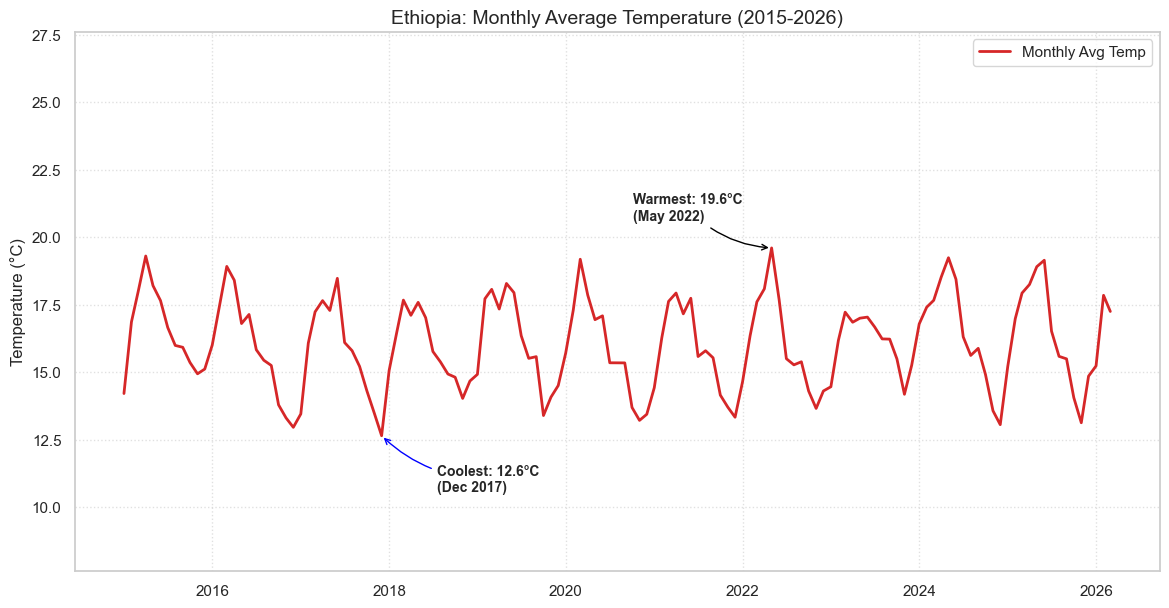

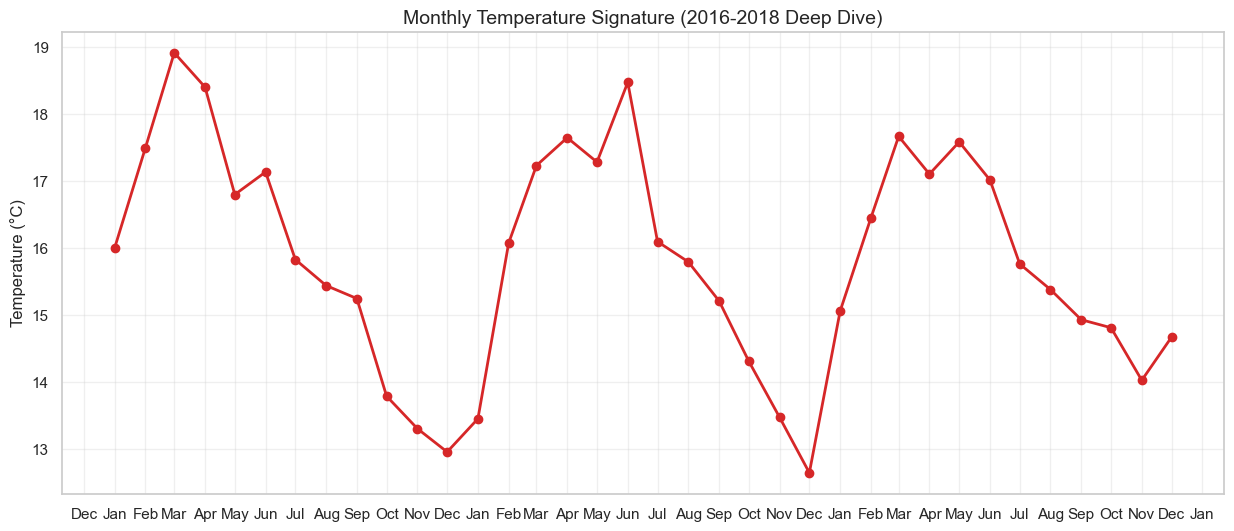

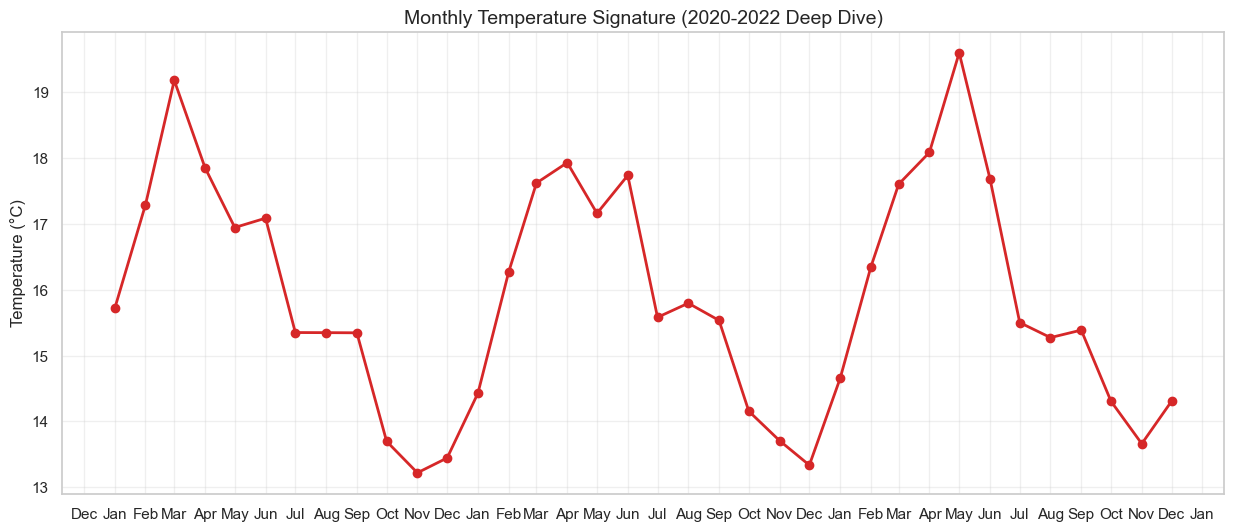

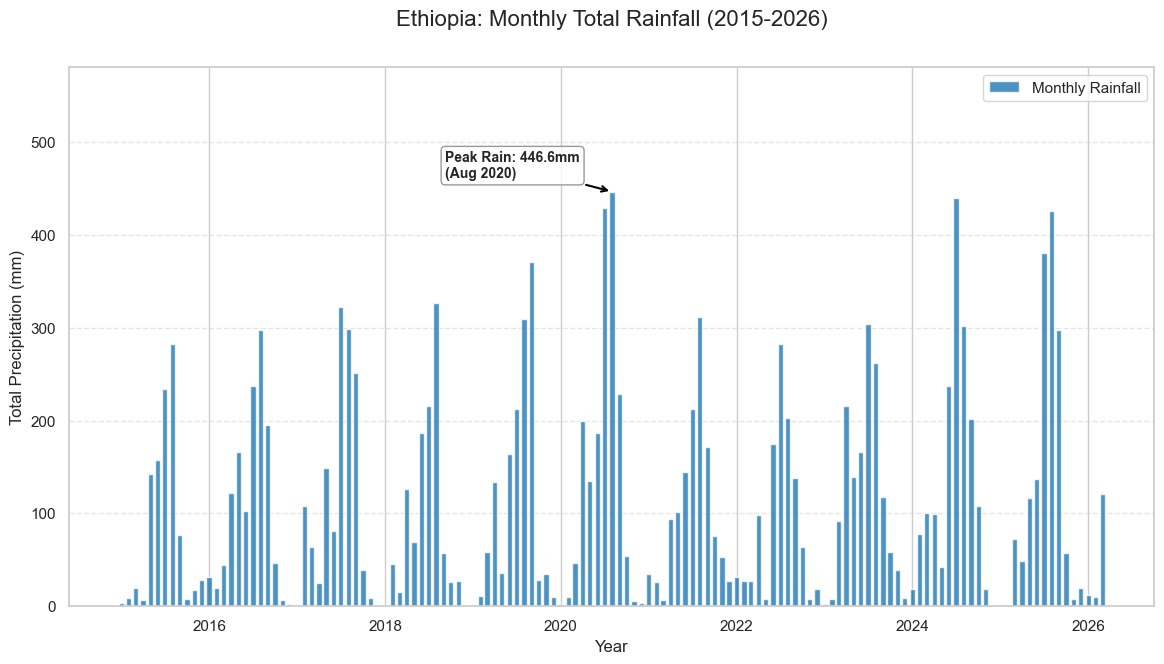

In [8]:
## Temperature Line Chart (T2M) with annotations
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date is datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
temp_df = df.set_index('Date')['T2M'].resample('MS').mean()

# Find warmest and coolest for annotation
warmest_date = temp_df.idxmax()
warmest_val = temp_df.max()
coolest_date = temp_df.idxmin()
coolest_val = temp_df.min()

plt.figure(figsize=(14, 7))
plt.plot(temp_df.index, temp_df, color='#d62728', linewidth=2, label='Monthly Avg Temp')

# Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), xytext=(-100, 20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black', connectionstyle="arc3,rad=.2"), fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), xytext=(40, -40),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue', connectionstyle="arc3,rad=-.2"), fontsize=10, fontweight='bold')

plt.ylim(temp_df.min() - 5, temp_df.max() + 8)
plt.title('Ethiopia: Monthly Average Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

import matplotlib.dates as mdates

# Filter data for a 2-year window to see months clearly for better analysis
# 1) 2016 - 2018

plt.figure(figsize=(15, 6))

zoom_df = temp_df['2016':'2018'] 

plt.plot(zoom_df.index, zoom_df, marker='o', color='#d62728', linewidth=2)

# This is the magic part: Force month labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Mark every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Show 'Jan', 'Feb', etc.

# Add the Year below the months
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_formatter(mdates.DateFormatter('\n\n%Y'))

plt.title('Monthly Temperature Signature (2016-2018 Deep Dive)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# 2) 2020 - 2022

plt.figure(figsize=(15, 6))

zoom_df = temp_df['2020':'2022'] 

plt.plot(zoom_df.index, zoom_df, marker='o', color='#d62728', linewidth=2)

# This is the magic part: Force month labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Mark every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Show 'Jan', 'Feb', etc.

# Add the Year below the months
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_formatter(mdates.DateFormatter('\n\n%Y'))

plt.title('Monthly Temperature Signature (2020-2022 Deep Dive)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

## Rainfall Bar Chart (PRECTOTCORR)

# Calculate Monthly Total Rainfall
rain_df = df.set_index('Date')['PRECTOTCORR'].resample('MS').sum()

# Identify peak month
peak_rain_date = rain_df.idxmax()
peak_rain_val = rain_df.max()

plt.figure(figsize=(14, 7))
plt.bar(rain_df.index, rain_df, width=22, color='#1f77b4', alpha=0.8, label='Monthly Rainfall')

# Annotate Peak
plt.annotate(f'Peak Rain: {peak_rain_val:.1f}mm\n({peak_rain_date.strftime("%b %Y")})', 
             xy=(peak_rain_date, peak_rain_val), xytext=(-120, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.ylim(0, rain_df.max()*1.3)
plt.title('Ethiopia: Monthly Total Rainfall (2015-2026)', fontsize=16, pad=30)
plt.ylabel('Total Precipitation (mm)')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Analysis of Climate Trends (2015-2026):

* Seasonal Temperature and Rainfall Dynamics

    * Thermal Trends: The analysis reveals a consistent annual "heat build-up" phase starting in February and peaking in June. This aligns with the Belg (short rainy season) where rising temperatures drive convective activity.

    * The July-August Cooling Anomaly: Interestingly, despite being the Northern Hemisphere summer, temperatures begin a sharp decline in July. This "cooling" is not caused by the season, but by the heavy cloud cover and high precipitation of the Kiremt (main rainy season), which blocks solar radiation and cools the land surface.

    * Historical Extremes: * 2016–2018 (The Cool Period): The data shows a sustained period of lower-than-average temperatures. This correlates with the recovery phase following the intense 2015/16 El Niño drought.

        * 2020–2022 (The Warm Period): The rising peaks during these years indicate a warming trend that may be linked to regional climate shifts or the triple-dip La Niña event that affected East African weather patterns during this window.

* Precipitation Profile & Extreme Events

    * Primary Rainy Season (Kiremt): The bar chart clearly illustrates a "unimodal" dominant rainfall pattern, with the vast majority of annual precipitation concentrated between June and September. This highlights the country's high dependency on this specific seasonal window for agriculture and hydroelectric power.

    * Peak Rainfall Event (August 2022): The analysis identifies August 2022 as the highest rainfall month in the 11-year record.

        * Significance: This peak corresponds with regional climate reports of an intensified Kiremt season. From a policy perspective, such extremes underscore the need for robust flood-management infrastructure in the Ethiopian highlands.

    * Dry Season (Bega) Vulnerability: The months of October through January consistently show near-zero rainfall across the full period. The stark contrast between the August peaks and the December troughs emphasizes Ethiopia's "water storage gap"—the period where the population relies entirely on stored water and irrigation.

    * Inter-annual Variability: While the seasonal timing is consistent, the "height" of the bars varies significantly year-to-year. The lower totals seen in 2015 (linked to a global El Niño) versus the abundance in 2022 demonstrate the impact of large-scale atmospheric oscillations on local food security.



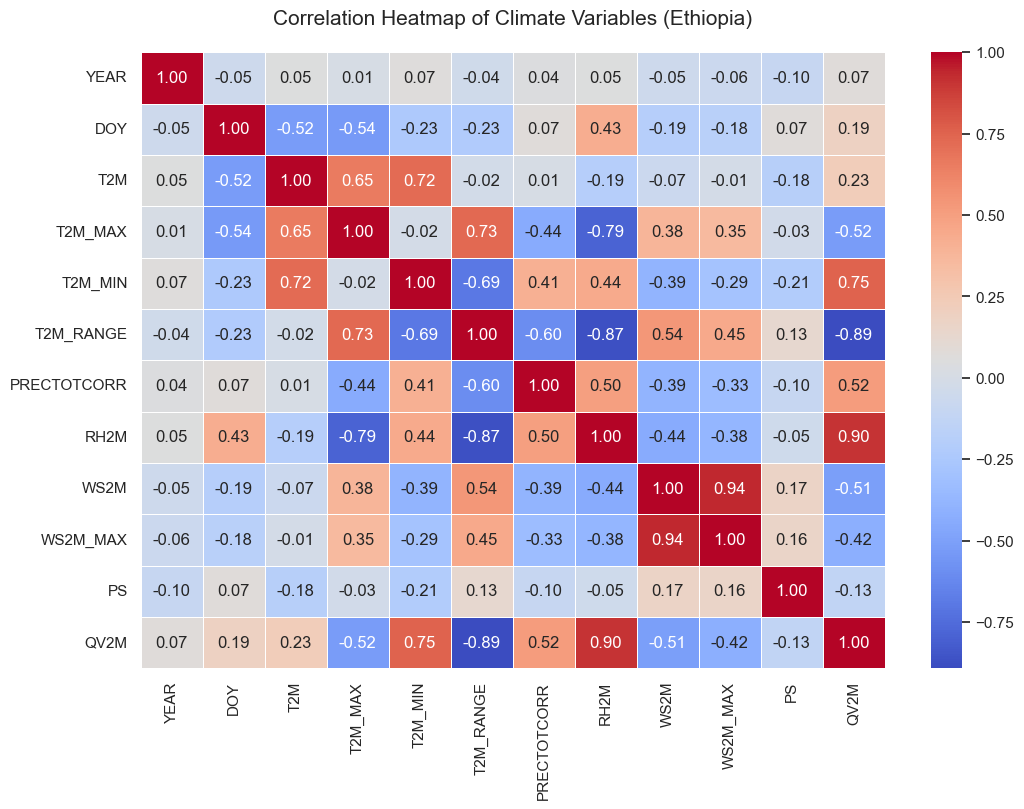

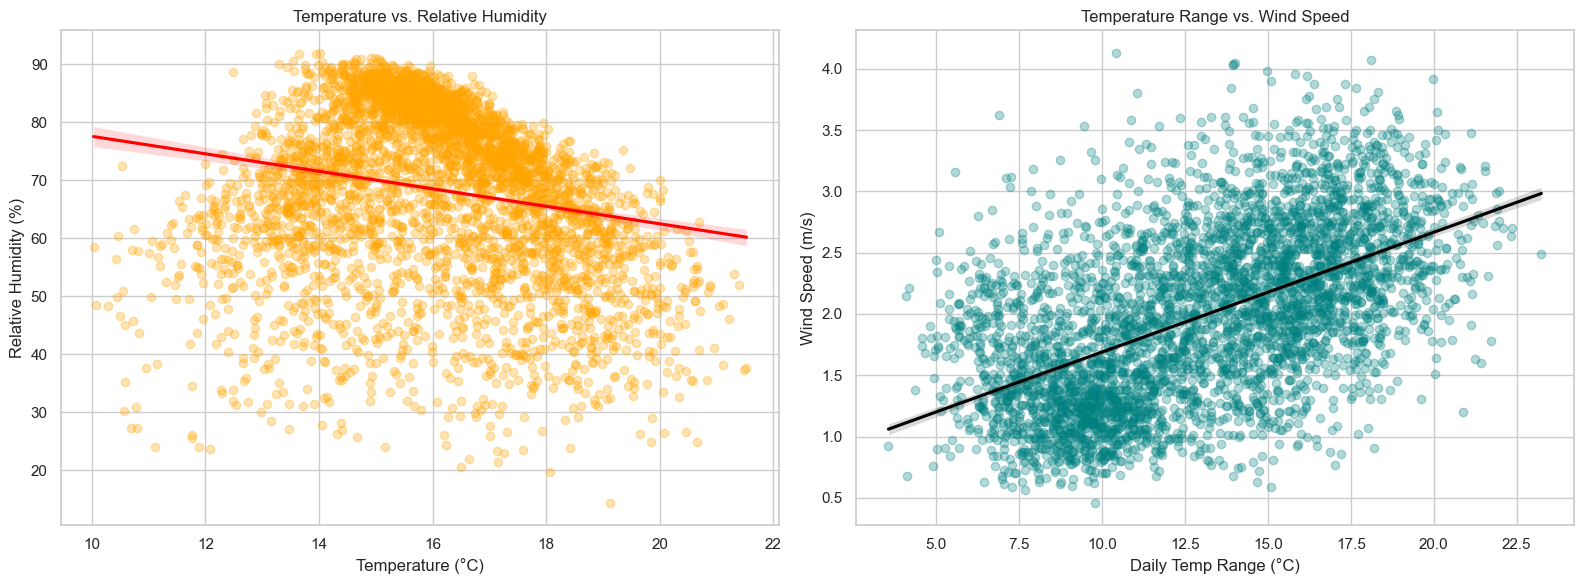

In [9]:
## Correlation Heatmap

import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables (Ethiopia)', fontsize=15, pad=20)
plt.show()

## Scatter Plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs RH2M
sns.regplot(data=df, x='T2M', y='RH2M', ax=ax1, 
            scatter_kws={'alpha':0.3, 'color':'orange'}, line_kws={'color':'red'})
ax1.set_title('Temperature vs. Relative Humidity')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: T2M_RANGE vs WS2M
sns.regplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'black'})
ax2.set_title('Temperature Range vs. Wind Speed')
ax2.set_xlabel('Daily Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

* Interpreting the Top 3 Correlations

1. WS2M and WS2M_MAX (0.94) — [Strong Positive Correlation]

    * Scientific Meaning: This shows a very high consistency in wind behavior. It indicates that when the average wind speed increases, the peak gusts (Max) increase proportionally.

    * Climate Insight: For Ethiopia, this suggests that wind patterns are relatively stable and predictable rather than being dominated by sudden, erratic bursts or microbursts. This is important for assessing wind energy potential or soil erosion risks in the highlands.

2. QV2M (Specific Humidity) and RH2M (Relative Humidity) (0.90) — [Strong Positive Correlation]

    * Scientific Meaning: QV2M measures the actual amount of water vapor in the air, while RH2M measures how "saturated" the air is. A 0.90 correlation means that in Ethiopia, the "feeling" of humidity is driven almost entirely by the actual moisture content present.

    * Climate Insight: This confirms that the rainy seasons (Kiremt and Belg) are driven by massive inflows of actual moisture (likely from the Indian Ocean and Gulf of Guinea) rather than just temperature changes causing condensation.

3. QV2M (Specific Humidity) and T2M_RANGE (-0.89) — [Strong Negative Correlation]

    * Scientific Meaning: This is the most "scientific" find of the three. It shows that as moisture in the air (QV2M) increases, the gap between the day's high and night's low (T2M_RANGE) shrinks significantly.

    * Climate Insight: Water vapor acts as a "thermal blanket." In the dry season, the lack of moisture allows the ground to heat up rapidly during the day and lose heat rapidly at night (high range). During the humid rainy season, the moisture traps outgoing heat at night and cloud cover blocks incoming heat during the day, creating a very stable, narrow temperature range.


* Scatter Plots

1. Temperature vs. Relative Humidity: The "Cloud Cooling" Effect

    * The Trend: The distinct downward slope from (10°C,80%) to (21°C,60%) confirms a strong inverse relationship. In the Ethiopian highlands, higher moisture levels are strictly associated with cooler temperatures.

    * The Accumulation: The heavy saturation of data points between 14°C and 18°C above the trend line suggests that the atmosphere often maintains higher-than-average humidity even as it warms, likely due to the "trap" effect of the mountainous terrain which holds onto moisture during the rainy season.

2. Temperature vs. Wind Speed: Convective Forcing

    * The Trend: The upward slope from (3°C,1m/s) to (23°C,3m/s) indicates that as the Ethiopian plateau heats up, wind speeds increase.

    * The Distribution: The even spread of points between 5°C and 21°C suggests that wind in Ethiopia is driven by thermal convection—as the ground warms, the air rises and creates surface wind. The lack of "tightness" in this cluster shows that wind is also influenced by seasonal pressure systems, not just daily heat.

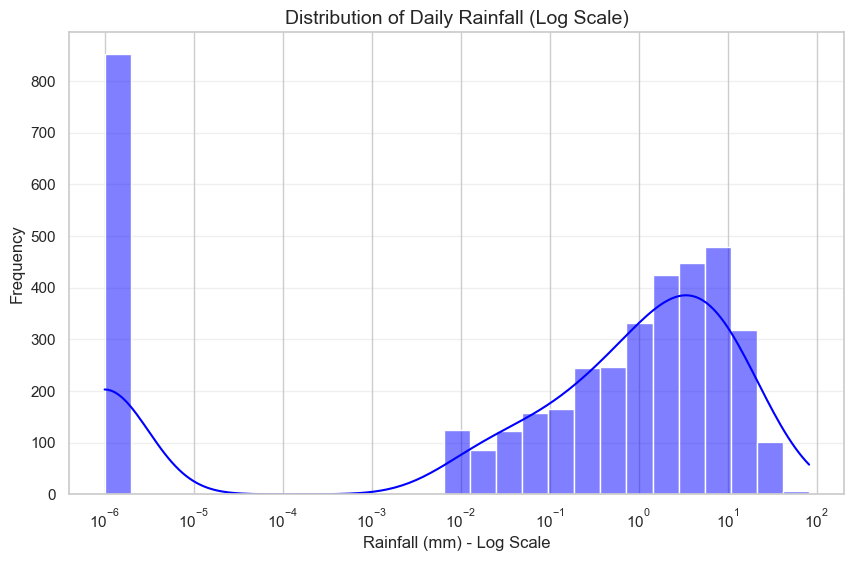

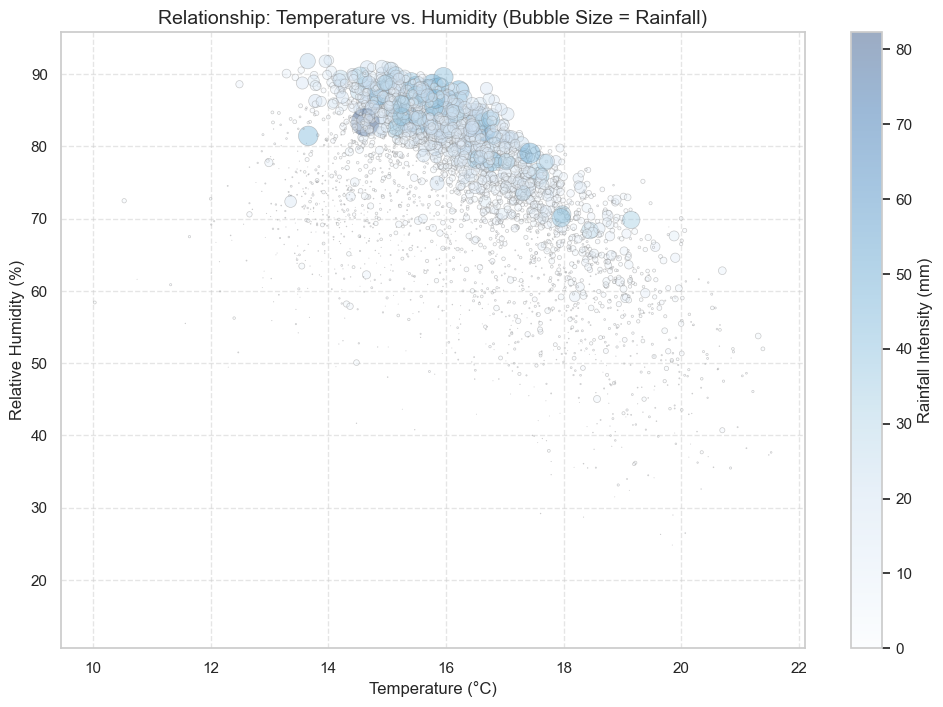

In [10]:
## Histogtam of Rainfall (PRECTOTCORR)

plt.figure(figsize=(10, 6))

# We add a tiny constant (1e-6) to avoid log(0) errors for dry days
sns.histplot(df['PRECTOTCORR'] + 1e-6, kde=True, color='blue', log_scale=True)

plt.title('Distribution of Daily Rainfall (Log Scale)', fontsize=14)
plt.xlabel('Rainfall (mm) - Log Scale')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Bubble Chart: T2M vs. RH2M (Size=Rain)

plt.figure(figsize=(12, 8))

# Create the scatter/bubble plot
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR']*5, # Scaling factor to make bubbles visible
                      alpha=0.4, 
                      c=df['PRECTOTCORR'], # Color also mapped to rain for clarity
                      cmap='Blues', 
                      edgecolors='grey', 
                      linewidth=0.5)

# Add a colorbar to show rain intensity
cbar = plt.colorbar(scatter)
cbar.set_label('Rainfall Intensity (mm)')

plt.title('Relationship: Temperature vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

* Rainfall Distribution & Variable Interaction

    * Bimodal Rainfall Distribution: The log-scale histogram reveals a bimodal characteristic. The primary spike at the minimum value (10^-6) confirms the prevalence of arid conditions for the majority of the year. The second "bell-shaped" curve peaking between 1mm and 100mm (10^0−10^2) captures the intensity of the Kiremt monsoon rains. This gap between "no rain" and "heavy rain" indicates a climate of extremes with very little middle ground.

    * Atmospheric "Sweet Spot" for Precipitation: The bubble chart demonstrates that significant rainfall (large bubbles) is not randomly distributed. It is heavily clustered in the High Relative Humidity (>60%) and Moderate Temperature (18°C−24°C) zone.

    * The Cooling Effect of Rain: A visible trend in the bubble chart is the absence of large bubbles at the highest temperature ranges. This confirms that precipitation events in the Ethiopian highlands are coupled with atmospheric cooling, likely due to evapotranspiration and dense cloud cover during peak rain months like August 2022.